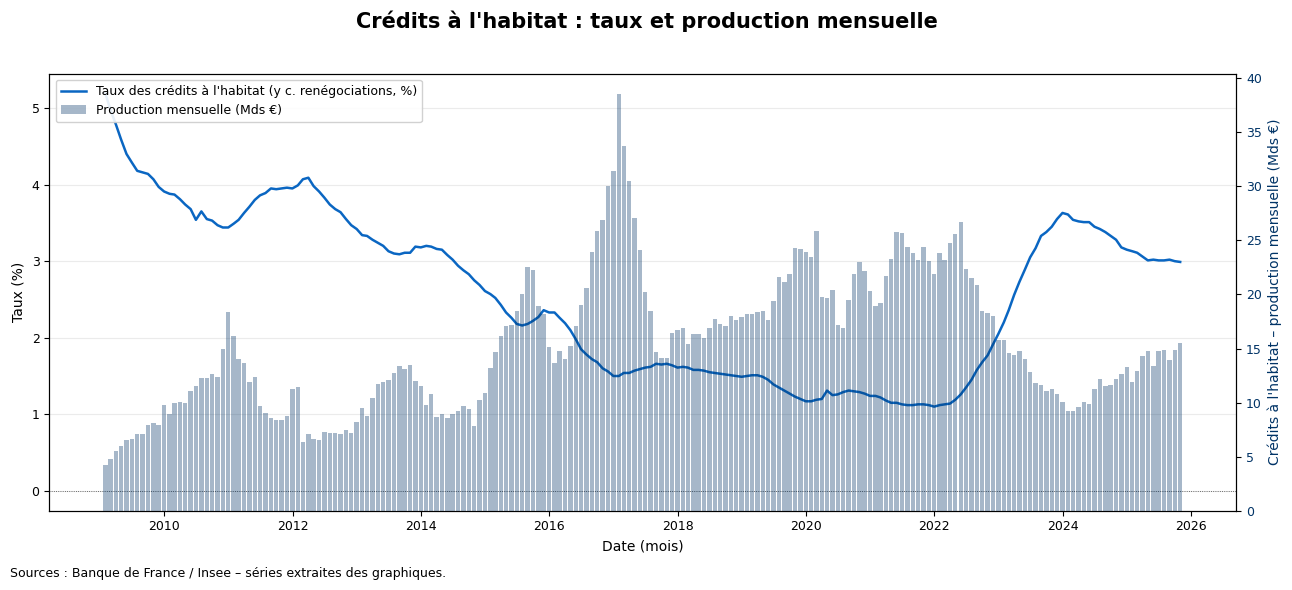

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 0. File paths (adapt to your own paths / filenames)
# -------------------------------------------------------------
PATH_TAUX   = r"C:\Users\GODLEWSKI\Downloads\chart (1).csv"
PATH_CREDIT = r"C:\Users\GODLEWSKI\Downloads\chart.csv"

# -------------------------------------------------------------
# 1. Helpers
# -------------------------------------------------------------
def to_float_series(s: pd.Series) -> pd.Series:
    """
    Convert a string column with French decimal comma to float.
    """
    return (
        s.astype(str)
         .str.replace("\u00a0", "")  # remove non-breaking spaces
         .str.replace(",", ".")
         .replace("nan", pd.NA)
         .astype(float)
    )

MONTH_MAP = {
    "janv.": 1,
    "févr.": 2,
    "mars": 3,
    "avr.": 4,
    "mai": 5,
    "juin": 6,
    "juil.": 7,
    "août": 8,
    "sept.": 9,
    "oct.": 10,
    "nov.": 11,
    "déc.": 12,
}

def parse_french_month(cat: str) -> pd.Timestamp:
    """
    Convert 'janv. 2009' -> Timestamp(2009-01-31) (month-end).
    """
    cat = str(cat).strip()
    parts = cat.split()
    if len(parts) != 2:
        return pd.NaT
    m_str, y_str = parts
    month = MONTH_MAP[m_str]
    year = int(y_str)
    return pd.Timestamp(year, month, 1) + pd.offsets.MonthEnd(0)

# -------------------------------------------------------------
# 2. Read and clean the 2 CSV files
# -------------------------------------------------------------
df_taux   = pd.read_csv(PATH_TAUX,   sep=";")
df_credit = pd.read_csv(PATH_CREDIT, sep=";")

for df in (df_taux, df_credit):
    df["date"] = df["Category"].apply(parse_french_month)

df_taux["taux_incl_renego"] = to_float_series(
    df_taux["Taux y compris renégociations"]
)
df_credit["credit_total"] = to_float_series(
    df_credit["Crédit à l'habitat total"]
)

# -------------------------------------------------------------
# 3. Merge on date (outer join) and keep full period
# -------------------------------------------------------------
merged = (
    df_taux[["date", "taux_incl_renego"]]
    .merge(df_credit[["date", "credit_total"]], on="date", how="outer")
    .sort_values("date")
    .set_index("date")
)

# (optional) If you prefer to require both series present, use:
# merged = merged.dropna(subset=["taux_incl_renego", "credit_total"])

# -------------------------------------------------------------
# 4. Plot: 2 y-axes, bars for credit, line for rate
# -------------------------------------------------------------
fig, ax_left = plt.subplots(figsize=(13, 6))

COLOR_TAUX = "#0A66C2"   # rate line
COLOR_PROD = "#003366"   # credit bars

# Left axis: rate
ax_left.plot(
    merged.index,
    merged["taux_incl_renego"],
    label="Taux des crédits à l'habitat (y c. renégociations, %)",
    color=COLOR_TAUX,
    linewidth=1.8,
)
ax_left.set_ylabel("Taux (%)")
ax_left.set_xlabel("Date (mois)")
ax_left.axhline(0, color="#444", linewidth=0.6, linestyle=":")
ax_left.grid(axis="y", alpha=0.25)
ax_left.set_axisbelow(True)

# Right axis: credit production in bars
ax_right = ax_left.twinx()
ax_right.set_ylabel("Crédits à l'habitat – production mensuelle (Mds €)", color=COLOR_PROD)

width_days = 25  # visual width of bars

ax_right.bar(
    merged.index,
    merged["credit_total"],
    width=width_days,
    color=COLOR_PROD,
    alpha=0.35,
    label="Production mensuelle (Mds €)",
    align="center",
)
ax_right.tick_params(axis="y", labelcolor=COLOR_PROD)

# -------------------------------------------------------------
# 5. Legend and cosmetics
# -------------------------------------------------------------
lines_l, labels_l = ax_left.get_legend_handles_labels()
lines_r, labels_r = ax_right.get_legend_handles_labels()

ax_left.legend(
    lines_l + lines_r,
    labels_l + labels_r,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    fontsize=9,
)

fig.suptitle(
    "Crédits à l'habitat : taux et production mensuelle",
    fontsize=15,
    fontweight="bold",
    y=0.96,
)

fig.text(
    0.01,
    0.01,
    "Sources : Banque de France / Insee – séries extraites des graphiques.",
    fontsize=9,
    ha="left",
    va="bottom",
)

ax_left.tick_params(axis="both", labelsize=9)
ax_right.tick_params(axis="y", labelsize=9)

ax_right.grid(False)

fig.tight_layout(rect=(0, 0.03, 1, 0.94))
plt.show()
